<a href="https://colab.research.google.com/github/niclohan/CalculoNumerico/blob/main/Atividade1_CN(Corrigido).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Membros**

Livia Kaori Shiba 185281

Nicollas Lohan 164928

# **1.Bibliotecas**


*   numpy - utilizado para cálculos numéricos
*   matplotlib - utilizado para plotar gráficos
* pandas - utilizado para montagem de tabelas
* matplotlib.animation - utilizado para fazer o gif
* IPython.display - utilizado para criar o quadro único demonstrativo PNG




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# **2.Definição de função**

*  arredondamento: considera o primeiro algarismo descartado.
*  truncamento: simplesmente elimina os algarismos posteriores à casa escolhida.
*  O erro absoluto tem a mesma unidade da grandeza.
*  O erro relativo não tem unidade e considera a escala do problema.
*  O erro percentual é o erro relativo expresso em porcentagem.


In [2]:
# Truncamento
def truncar(x, n): # Trunca o número x para n casas decimais.
    fator = 10**n
    return np.trunc(x * fator) / fator


# Arredondamento
def arredondar(x, n): # Arredonda o número x para n casas decimais.
    return round(x, n)


# Erro absoluto
def calcular_erro_absoluto(valor_referencia, valor_aproximado):   # Calcula a distância entre o valor de referência e a aproximação.
    return abs(valor_referencia - valor_aproximado)


# Erro relativo
def calcular_erro_relativo(valor_referencia, valor_aproximado):   # Calcula o erro absoluto e divide pelo módulo do valor de referência.
    erro_absoluto = abs(valor_referencia - valor_aproximado)
    return erro_absoluto / abs(valor_referencia)


# Erro percentual
def calcular_erro_percentual(valor_referencia, valor_aproximado):   # Converte o erro relativo em porcentagem.
    erro_relativo = calcular_erro_relativo(
        valor_referencia,
        valor_aproximado
    )
    return 100 * erro_relativo


erro_absoluto = calcular_erro_absoluto
erro_relativo = calcular_erro_relativo
erro_percentual = calcular_erro_percentual

# **3. Parte A - Truncamento e Arredondamento**

Vamos definir os valores:

In [3]:
#Dados do Problema
valores = [
    3.14159265,
    98.76543,
    0.00498765
]
casas = [0, 1, 2, 3, 4]

Agora vamos gerar a tabela:

In [4]:
resultados_A = []

for x in valores:
  for n in casas:

    trunc = truncar(x, n)
    arred = arredondar(x, n)

    resultados_A.append({
            "Valor": x,
            "Casas": n,
            "Truncamento": trunc,
            "Arredondamento": arred,
            "Ea trunc": erro_absoluto(x, trunc),
            "Er trunc": erro_relativo(x, trunc),
            "E% trunc": erro_percentual(x, trunc),
            "Ea arred": erro_absoluto(x, arred),
            "Er arred": erro_relativo(x, arred),
            "E% arred": erro_percentual(x, arred)
        })

tabela_A = pd.DataFrame(resultados_A)

tabela_A

,Valor,Casas,Truncamento,Arredondamento,Ea trunc,Er trunc,E% trunc,Ea arred,Er arred,E% arred
0,3.141593,0,3.0000,3.0000,0.141593,4.507034e-02,4.507034,0.141593,4.507034e-02,4.507034
1,3.141593,1,3.1000,3.1000,0.041593,1.323935e-02,1.323935,0.041593,1.323935e-02,1.323935
2,3.141593,2,3.1400,3.1400,0.001593,5.069562e-04,0.050696,0.001593,5.069562e-04,0.050696
3,3.141593,3,3.1410,3.1420,0.000593,1.886464e-04,0.018865,0.000407,1.296635e-04,0.012966
4,3.141593,4,3.1415,3.1416,0.000093,2.949141e-05,0.002949,0.000007,2.339578e-06,0.000234
5,98.765430,0,98.0000,99.0000,0.765430,7.749979e-03,0.774998,0.234570,2.375021e-03,0.237502
6,98.765430,1,98.7000,98.8000,0.065430,6.624788e-04,0.066248,0.034570,3.500213e-04,0.035002
7,98.765430,2,98.7600,98.7700,0.005430,5.497875e-05,0.005498,0.004570,4.627125e-05,0.004627
8,98.765430,3,98.7650,98.7650,0.000430,4.353750e-06,0.000435,0.000430,4.353750e-06,0.000435
9,98.765430,4,98.7654,98.7654,0.000030,3.037500e-07,0.000030,0.000030,3.037500e-07,0.000030


Agora para o gráfico do erro absoluto:

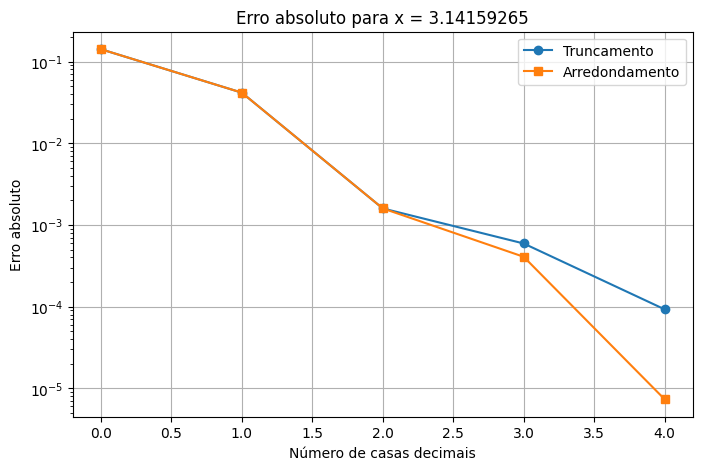

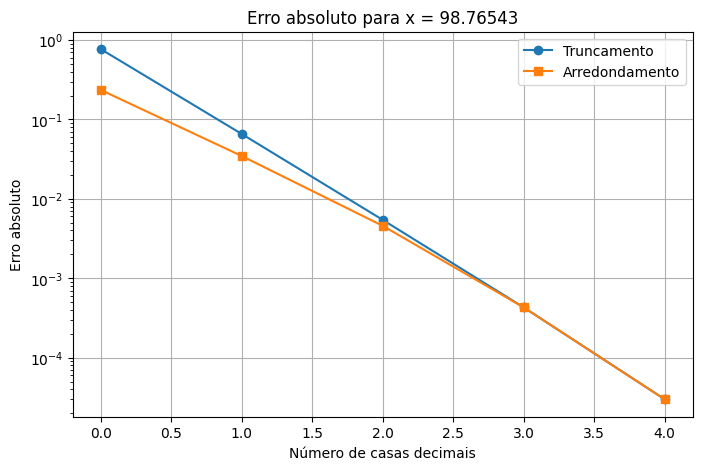

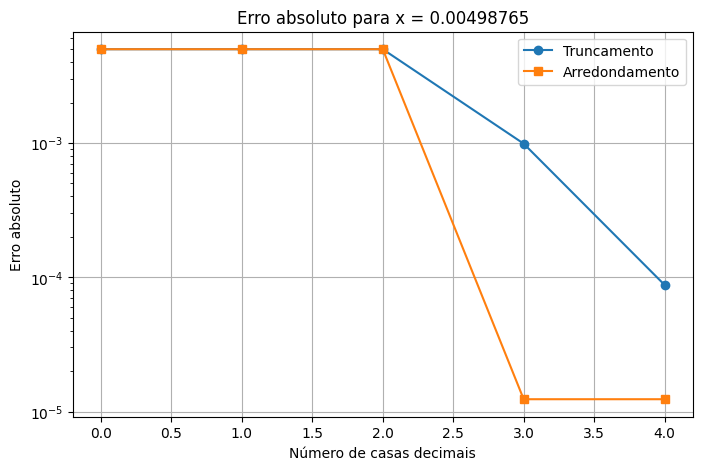

In [5]:
for x in valores:

    dados = tabela_A[tabela_A["Valor"] == x]

    plt.figure(figsize=(8, 5))

    plt.semilogy(
        dados["Casas"],
        dados["Ea trunc"],
        marker="o",
        label="Truncamento"
    )

    plt.semilogy(
        dados["Casas"],
        dados["Ea arred"],
        marker="s",
        label="Arredondamento"
    )

    plt.xlabel("Número de casas decimais")
    plt.ylabel("Erro absoluto")
    plt.title(f"Erro absoluto para x = {x}")
    plt.grid(True)
    plt.legend()

    plt.show()

**Pergunta:** Arredondar sempre gera erro menor ou igual ao truncamento?

**Resposta:** Para os valores positivos analisados e para a regra usual de arredondamento, o arredondamento tende a produzir erro menor ou igual ao truncamento. Isso ocorre porque ele considera o primeiro algarismo descartado para decidir se deve aumentar ou manter o último algarismo. Os resultados da tabela permitem verificar isso numericamente para cada caso.

#**4.  Parte B — Medidas de Pressão arterial**

## **B.1 - Vamos definir as medidas de pressão arterial:**

In [6]:
#Dados Originais
pressao = np.array([121.7, 120.4, 122.1, 119.8, 121.2,
    120.9, 122.4, 121.0, 120.2, 121.5])
pressao_original = pressao

In [7]:
#Dados Arredondados para o inteiro mais proximo:
pressao_arred_int = np.round(pressao).astype(int)

In [8]:
#Truncadas para inteiro:
pressao_trunc_int = np.trunc(pressao).astype(int)
pressao_arred_1 = np.round(pressao, 1)

Média de Referência:

In [9]:
media_referencia = np.mean(pressao)

print(f"Média de referência: {media_referencia:.10f} mmHg")

Média de referência: 121.1200000000 mmHg


Agora as estatísticas:
*   Media
*   Minimo
*   Máximo
*   Amplitude
*   Desvio Padrão Amostral



In [10]:
def estatisticas(serie):
    return {
        "Média": np.mean(serie),
        "Mínimo": np.min(serie),
        "Máximo": np.max(serie),
        "Amplitude": np.max(serie) - np.min(serie),
        "Desvio padrão amostral": np.std(serie, ddof=1)
    }

In [11]:
series_pressao = {
    "Original": pressao_original,
    "Arredondada inteiro": pressao_arred_int,
    "Truncada inteiro": pressao_trunc_int,
    "Arredondada 1 casa": pressao_arred_1
}

estatisticas_pressao = pd.DataFrame({
    nome: estatisticas(serie)
    for nome, serie in series_pressao.items()
}).T

estatisticas_pressao

,Média,Mínimo,Máximo,Amplitude,Desvio padrão amostral
Original,121.12,119.8,122.4,2.6,0.833733
Arredondada inteiro,121.10,120.0,122.0,2.0,0.875595
Truncada inteiro,120.70,119.0,122.0,3.0,0.948683
Arredondada 1 casa,121.12,119.8,122.4,2.6,0.833733


Agora para os Erros:

In [12]:
medias = {
    nome: np.mean(serie)
    for nome, serie in series_pressao.items()
}

erros_medias = []

for nome, media in medias.items():

    erros_medias.append({
        "Série": nome,
        "Média": media,
        "Erro absoluto": erro_absoluto(
            media_referencia,
            media
        ),
        "Erro relativo": erro_relativo(
            media_referencia,
            media
        ),
        "Erro percentual": erro_percentual(
            media_referencia,
            media
        )
    })

tabela_erros_pressao = pd.DataFrame(erros_medias)

tabela_erros_pressao

,Série,Média,Erro absoluto,Erro relativo,Erro percentual
0,Original,121.12,0.00,0.000000,0.000000
1,Arredondada inteiro,121.10,0.02,0.000165,0.016513
2,Truncada inteiro,120.70,0.42,0.003468,0.346764
3,Arredondada 1 casa,121.12,0.00,0.000000,0.000000


## **B.2 - Gerando os gráficos:**

Gráfico das 4 Séries:

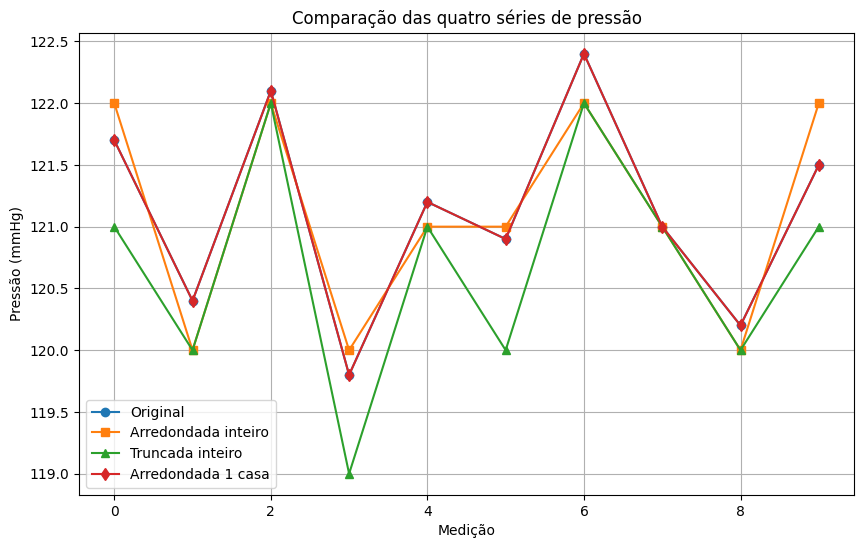

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    pressao_original,
    marker="o",
    label="Original"
)

plt.plot(
    pressao_arred_int,
    marker="s",
    label="Arredondada inteiro"
)

plt.plot(
    pressao_trunc_int,
    marker="^",
    label="Truncada inteiro"
)

plt.plot(
    pressao_arred_1,
    marker="d",
    label="Arredondada 1 casa"
)

plt.xlabel("Medição")
plt.ylabel("Pressão (mmHg)")
plt.title("Comparação das quatro séries de pressão")
plt.grid(True)
plt.legend()

plt.show()

Gráfico dos Erros Absolutos:

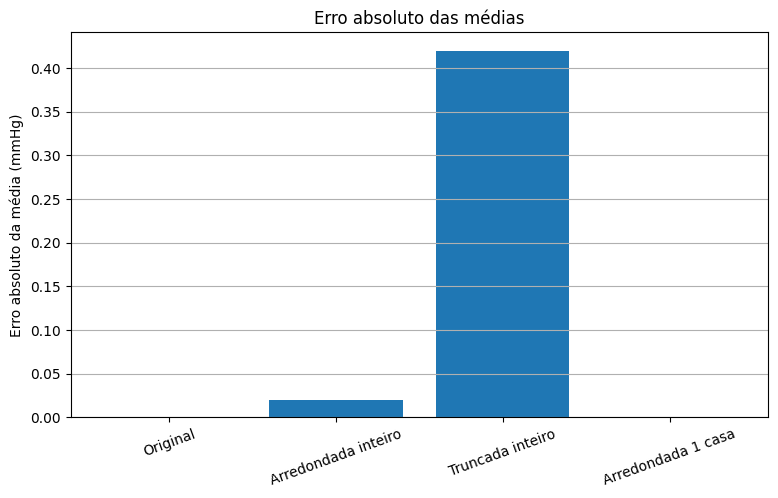

In [14]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabela_erros_pressao["Série"],
    tabela_erros_pressao["Erro absoluto"]
)

plt.ylabel("Erro absoluto da média (mmHg)")
plt.title("Erro absoluto das médias")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

Gráfico dos Erros Percentuais

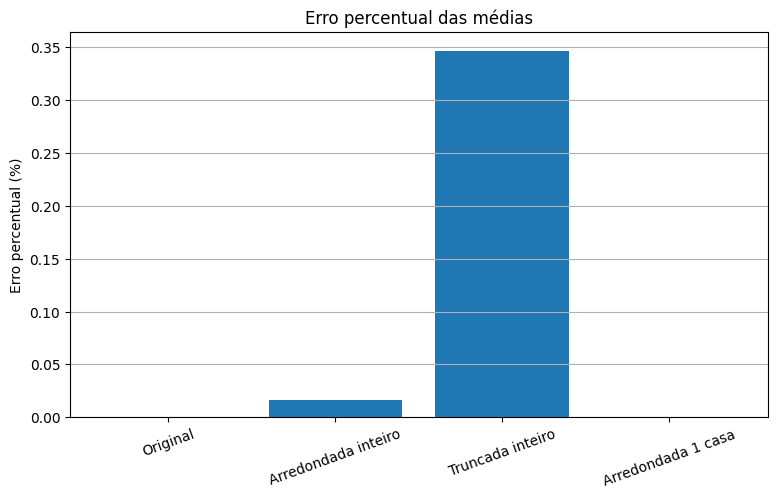

In [15]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabela_erros_pressao["Série"],
    tabela_erros_pressao["Erro percentual"]
)

plt.ylabel("Erro percentual (%)")
plt.title("Erro percentual das médias")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

Gráfico de Histograma:

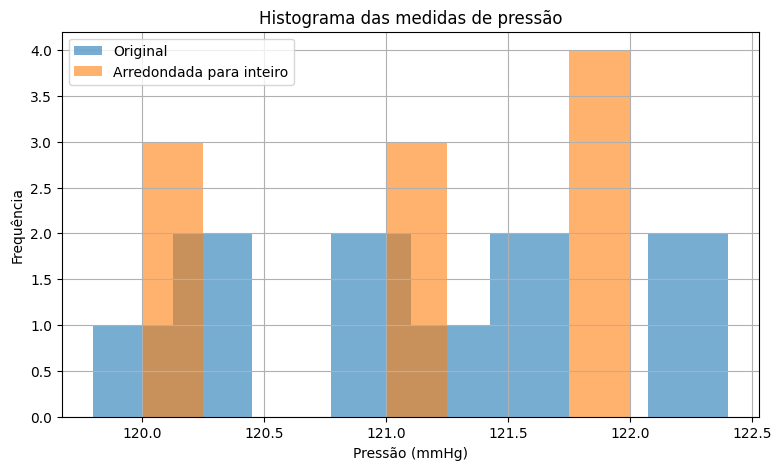

In [16]:
plt.figure(figsize=(9, 5))

plt.hist(
    pressao_original,
    bins=8,
    alpha=0.6,
    label="Original"
)

plt.hist(
    pressao_arred_int,
    bins=8,
    alpha=0.6,
    label="Arredondada para inteiro"
)

plt.xlabel("Pressão (mmHg)")
plt.ylabel("Frequência")
plt.title("Histograma das medidas de pressão")
plt.legend()
plt.grid(True)

plt.show()

**Análise dos Gráficos:**

A representação inteira preserva aproximadamente a faixa geral dos dados, mas reduz a resolução das medidas. Isso pode alterar a média e principalmente a representação da variabilidade, pois diferentes valores originais podem ser transformados no mesmo número inteiro. Portanto, para esta pequena amostra, a representação inteira pode ser suficiente para uma descrição aproximada, mas não preserva completamente as informações presentes nos dados originais. A análise é exclusivamente numérica e não envolve interpretação médica.

#**5. Parte C- vazão em um tubo de pequeno diâmetro**

Foi utilizado a a relação de Hagen–Poiseuille, para o calculo do vazemento laminar idealizado

Dados:

$$ r = 0,80 mm, L = 0,20 m, μ = 3,5 × 10−3 Pa s, ∆p = 1200 Pa
$$


**5. C1- precisão das variaveis**
Calcule Q usando:
1. todos os valores fornecidos;
2. r arredondado e truncado para uma casa decimal em mm;
3. μ arredondada e truncada para três casas decimais em Pa s;
4. ∆p arredondada e truncada para centenas de pascal;
5. todas as aproximações simultaneamente.
Calcule os erros de Q em cada cenário.



In [17]:
import numpy as np
import pandas as pd

# Helper functions for error calculation
def erro_absoluto(valor_calculado, valor_referencia):
  return abs(valor_calculado - valor_referencia)

def erro_relativo(valor_calculado, valor_referencia):
  # Handle division by zero if reference is zero
  if valor_referencia == 0:
    return float('inf') if valor_calculado != 0 else 0.0
  return abs((valor_calculado - valor_referencia) / valor_referencia)

def erro_percentual(valor_calculado, valor_referencia):
  return erro_relativo(valor_calculado, valor_referencia) * 100


#Dados disponibilizados:
#raio em metro
r = 0.80e-3

#Comprimento em metro
L = 0.20

#viscosidade laminar em Pa.s
mu = 3.5e-3

#variação de pressão em Pa
dp = 1200

#Calculo da vazão
def vazao(r, L, mu, dp):
  return (np.pi * r**4 * dp) / (8 * mu * L)

#Adicionar tudo na equação
Q_ref = vazao(r, L, mu, dp)
print(f"Q:{Q_ref:.10e} m³/s")


#Calculo de precisão das variaveis/ arredondamentos
r_mm = 0.80 # Corrected from 0,80 to 0.80

#Arrendondamento para 1 casa decimal do raio
r_arrend_mm = round(r_mm, 1)
r_trunc_mm = np.trunc(r_mm * 10) / 10 # Changed trunc to np.trunc

#truncamento e arredondamento do raio
r_arrend = r_arrend_mm * 1e-3
r_trunc = r_trunc_mm * 1e-3

#vazao arredondada e truncada em relação ao raio
Q_r_arrend = vazao(r_arrend, L, mu, dp)
Q_r_trunc = vazao(r_trunc, L, mu, dp)


#Arredondamento e truncamento da viscosidade
mu_arrend = round (mu, 3)
mu_trunc = np.trunc(mu * 1000) / 1000 # Changed trunc to np.trunc and adjusted for 3 decimals

#vazao arredondada e truncada em relação a viscosidade
Q_mu_arrend = vazao(r, L, mu_arrend, dp)
Q_mu_trunc = vazao(r, L, mu_trunc, dp)

#pressao  arredondada e truncada
dp_arrend = round (dp/ 100)*100
dp_trunc = np.trunc(dp/100)*100

#vazao arredondada e truncada em relação a pressão
Q_dp_arrend = vazao(r, L, mu, dp_arrend)
Q_dp_trunc = vazao (r, L, mu, dp_trunc)

#as aproximações
Q_todas_arrend = vazao(r_arrend, L, mu_arrend, dp_arrend)
Q_todas_trunc = vazao(r_trunc, L, mu_trunc, dp_trunc)

#tabela com os resultados obtidos
cenarios = {
    'Referência' : Q_ref,
    'Raio arredondado' : Q_r_arrend,
    'Raio truncado' : Q_r_trunc,
    'Viscosidade arredondada' : Q_mu_arrend,
    'Viscosidade truncada' : Q_mu_trunc,
    'Pressão arredondada' : Q_dp_arrend,
    'Pressão truncada' : Q_dp_trunc,
    'Todas as aproximações (Arredondado)' : Q_todas_arrend, # Changed key to be unique
    'Todas as aproximações (Truncado)' : Q_todas_trunc # Changed key to be unique

}

resultado_C = []

for nome, Q in cenarios.items():
  resultado_C.append([
      nome, Q,
      erro_absoluto(Q, Q_ref),
      erro_relativo(Q, Q_ref),
      erro_percentual(Q, Q_ref)
  ])

df_C = pd.DataFrame(resultado_C, columns=['Cenário',
                                          'Q', 'Erro Absoluto',
                                          'Erro Relativo',
                                          'Erro Percentual'])


display(df_C)


Q:2.7574207520e-07 m³/s


,Cenário,Q,Erro Absoluto,Erro Relativo,Erro Percentual
0,Referência,2.757421e-07,0.000000e+00,0.000000,0.000000
1,Raio arredondado,2.757421e-07,0.000000e+00,0.000000,0.000000
2,Raio truncado,2.757421e-07,0.000000e+00,0.000000,0.000000
3,Viscosidade arredondada,2.412743e-07,3.446776e-08,0.125000,12.500000
4,Viscosidade truncada,3.216991e-07,4.595701e-08,0.166667,16.666667
5,Pressão arredondada,2.757421e-07,0.000000e+00,0.000000,0.000000
6,Pressão truncada,2.757421e-07,0.000000e+00,0.000000,0.000000
7,Todas as aproximações (Arredondado),2.412743e-07,3.446776e-08,0.125000,12.500000
8,Todas as aproximações (Truncado),3.216991e-07,4.595701e-08,0.166667,16.666667


**5.C2-Sensibilidade ao raio**
O raio deve varias de 0,70 a 0,90 mm


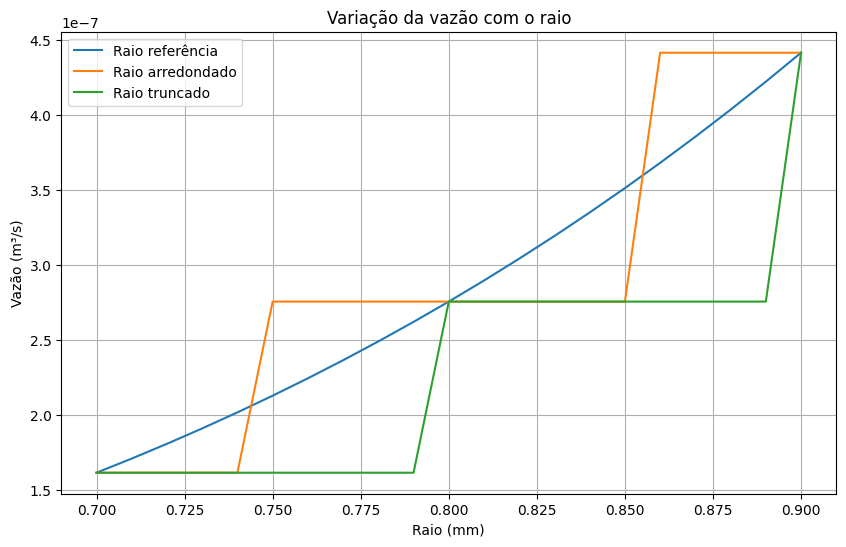

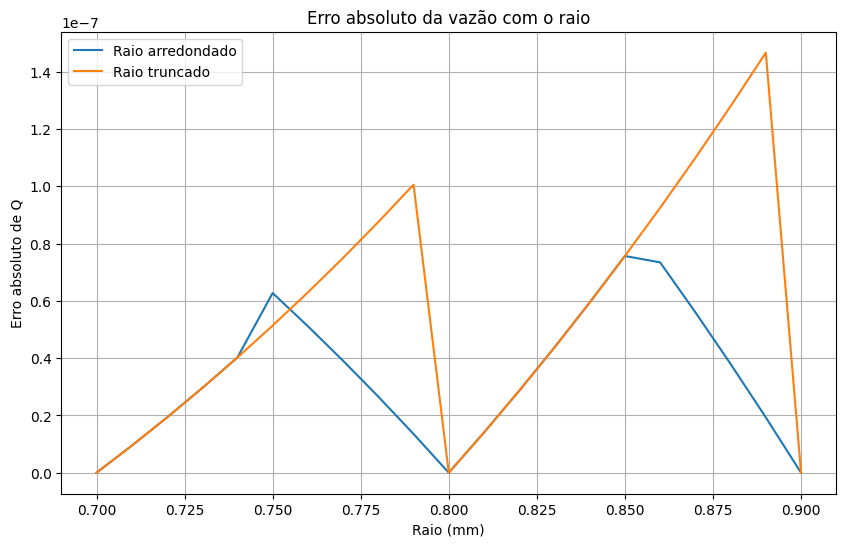

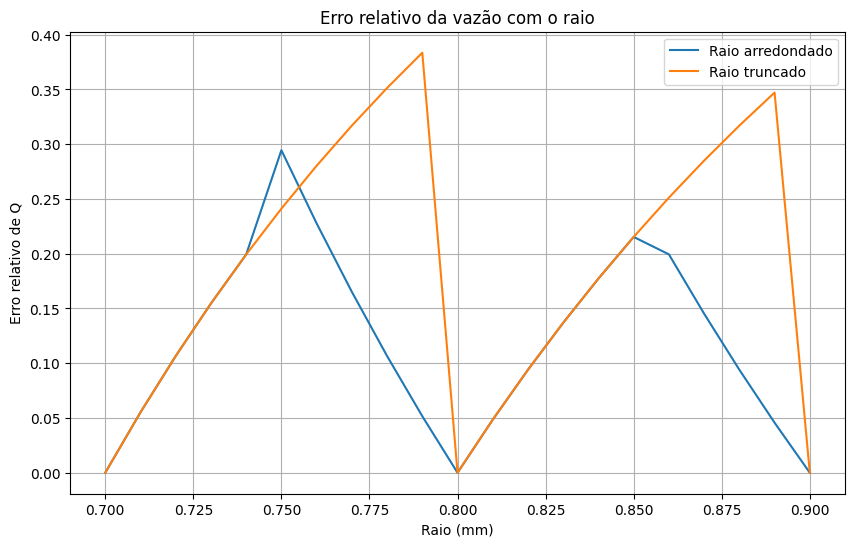

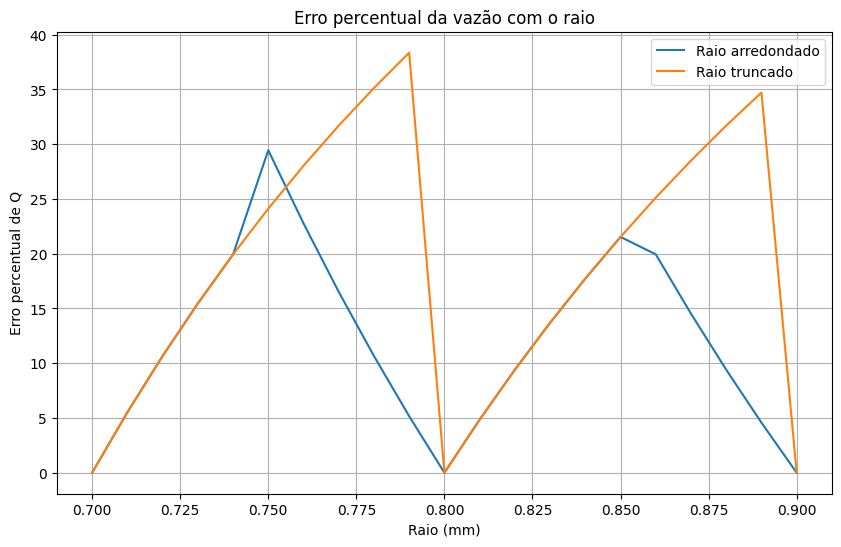

In [18]:
#Criando os valores de raio
raios_mm = np.arange(0.70, 0.901, 0.01)

#Convertendo raio para metros
raios_m = raios_mm * 1e-3

#Calculando a vazão de referência
Q_referencia = vazao (
    raios_m, L, mu, dp
)

#Arredondando o raio
raios_arrend = np.round(raios_mm, 1)

#truncando o raio
raios_trunc = np.trunc(raios_mm * 10) / 10

#vazão usando o raio arredondado
Q_arrend = vazao(
    raios_arrend * 1e-3, L, mu, dp
)

#vazão usando o raio truncado
Q_trunc = vazao(
    raios_trunc * 1e-3, L, mu, dp
)

#Erro absoluto
erro_abs_arrend = np.abs (Q_referencia - Q_arrend)
erro_abs_trunc = np.abs (Q_referencia - Q_trunc)

#Erro relativo
erro_rel_arrend = erro_abs_arrend / np.abs(Q_referencia)
erro_rel_trunc = erro_abs_trunc / np.abs(Q_referencia)

#Erro percentual
erro_perc_arrend = erro_rel_arrend * 100
erro_perc_trunc = erro_rel_trunc * 100

#Gráfico Qxr
plt.figure(figsize=(10, 6))

plt.plot(raios_mm, Q_referencia, label='Raio referência')
plt.plot(raios_mm, Q_arrend, label='Raio arredondado')
plt.plot(raios_mm, Q_trunc, label='Raio truncado')

plt.xlabel('Raio (mm)')
plt.ylabel('Vazão (m³/s)')
plt.title('Variação da vazão com o raio')
plt.legend()
plt.grid(True)
plt.show()

#Gráfico erro absoluto
plt.figure(figsize=(10, 6))

plt.plot(raios_mm, erro_abs_arrend, label='Raio arredondado')
plt.plot(raios_mm, erro_abs_trunc, label='Raio truncado')

plt.xlabel('Raio (mm)')
plt.ylabel('Erro absoluto de Q')
plt.title ('Erro absoluto da vazão com o raio')
plt.legend()
plt.grid(True)
plt.show()

#Gráfico do erro relativos
plt.figure(figsize=(10, 6))

plt.plot(raios_mm, erro_rel_arrend, label='Raio arredondado')
plt.plot(raios_mm, erro_rel_trunc, label='Raio truncado')

plt.xlabel('Raio (mm)')
plt.ylabel('Erro relativo de Q')
plt.title('Erro relativo da vazão com o raio')
plt.legend()
plt.grid(True)
plt.show()

#Gráfico do erro percentual
plt.figure(figsize=(10, 6))

plt.plot(raios_mm, erro_perc_arrend, label='Raio arredondado')
plt.plot(raios_mm, erro_perc_trunc, label='Raio truncado')

plt.xlabel('Raio (mm)')
plt.ylabel('Erro percentual de Q')
plt.title('Erro percentual da vazão com o raio')
plt.legend()
plt.grid(True)
plt.show()

**Explique por que o erro no raio é amplificado na vazão. Relacione sua resposta ao expoente
quatro.**

$$Q=πr^4Δp/8μL$$

Observando a equação de Hagen-Poiseuille, o raio está elevado à quarta potência, portanto, uma pequena variação no valor do raio produz uma variação de quarta potência na vazão. Isto, explica o porquê do raio ser amplificado na vazão.Além disso, erros pequenos em relação ao raio podem ser erros relativamente maiores na vazão.

# **6. Parte D - Escoamento de um Nanocateter**

Dados: $$ r=50 nm
,  L=10\mu m,  \mu=3,5\times10^{-3}\text{ Pa.s} ,Δp=5000 Pa $$

In [19]:
#Convertendo para metros:
r_nano = 50e-9
L_nano = 10e-6
mu_nano = 3.5e-3
dp_nano = 5000

In [20]:
#Calculando:
Q_nano = vazao(
    r_nano,
    L_nano,
    mu_nano,
    dp_nano
)

print(f"Q = {Q_nano:.10e} m³/s")

Q = 3.5062418009e-19 m³/s


## **D.1 - Erro Geométrico**

Os erros são:
$$ 0,1 ; 0,2 ; 0,3 ;…; 5,0 nm $$

In [21]:
dr_nm = np.arange(0.1, 5.0 + 0.1, 0.1)
dr_m = dr_nm * 1e-9

In [22]:
#Agora:
r_menos = r_nano - dr_m
r_mais = r_nano + dr_m

Q_menos = vazao(
    r_menos,
    L_nano,
    mu_nano,
    dp_nano
)

Q_mais = vazao(
    r_mais,
    L_nano,
    mu_nano,
    dp_nano
)

Erro Maximo:
Como existem duas direções:
* $$r-\Delta r$$
* $$r+\Delta r$$

Vamos pegar o maior erro:

In [23]:
erro_menos = np.abs(Q_menos - Q_nano)
erro_mais = np.abs(Q_mais - Q_nano)

erro_max = np.maximum(
    erro_menos,
    erro_mais
)

**Erro Relativo:**

In [24]:
erro_rel_max = erro_max / abs(Q_nano)

**Erro Percentual:**

In [25]:
erro_perc_max = 100 * erro_rel_max

**Grafico:**

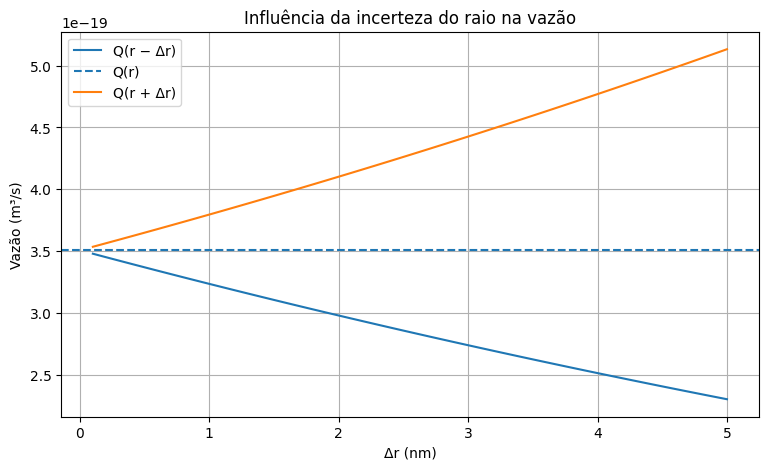

In [26]:
plt.figure(figsize=(9, 5))

plt.plot(
    dr_nm,
    Q_menos,
    label="Q(r − Δr)"
)

plt.axhline(
    Q_nano,
    linestyle="--",
    label="Q(r)"
)

plt.plot(
    dr_nm,
    Q_mais,
    label="Q(r + Δr)"
)

plt.xlabel("Δr (nm)")
plt.ylabel("Vazão (m³/s)")
plt.title("Influência da incerteza do raio na vazão")
plt.grid(True)
plt.legend()

plt.show()

**Erro Absoluto Maximo de Q:**

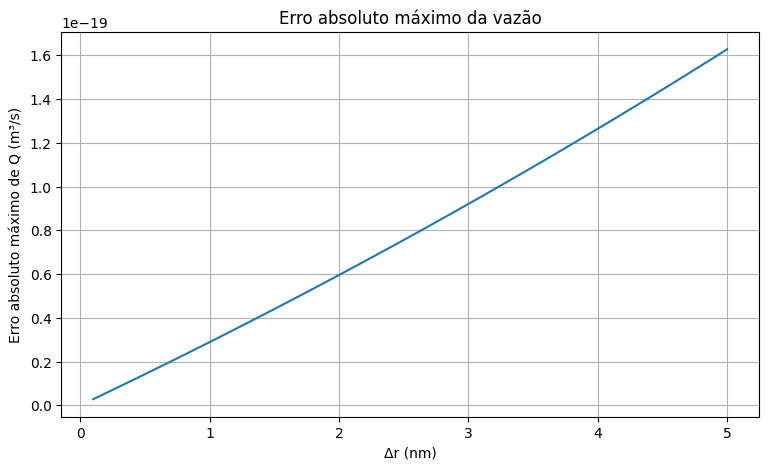

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    dr_nm,
    erro_max
)

plt.xlabel("Δr (nm)")
plt.ylabel("Erro absoluto máximo de Q (m³/s)")
plt.title("Erro absoluto máximo da vazão")
plt.grid(True)

plt.show()

**Erro Relativo Máximo de Q**

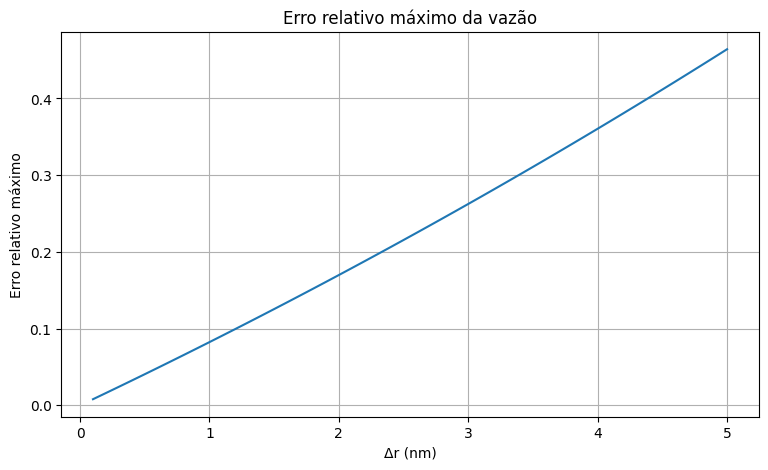

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    dr_nm,
    erro_rel_max
)

plt.xlabel("Δr (nm)")
plt.ylabel("Erro relativo máximo")
plt.title("Erro relativo máximo da vazão")
plt.grid(True)

plt.show()

**Erro Percentual Máximo de Q**

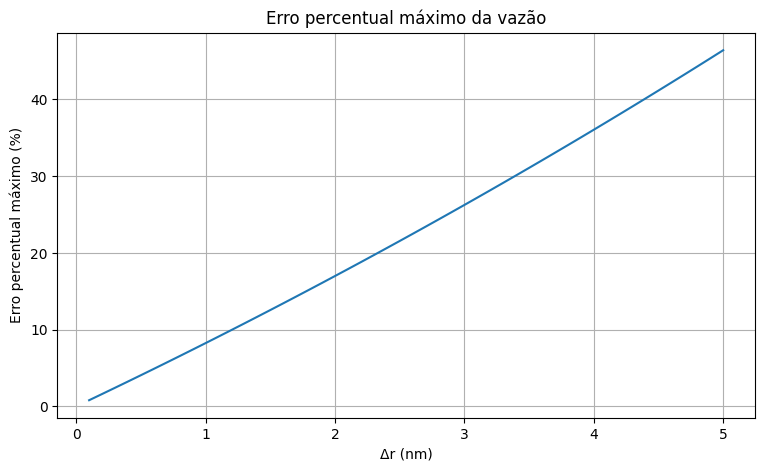

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(
    dr_nm,
    erro_perc_max
)

plt.xlabel("Δr (nm)")
plt.ylabel("Erro percentual máximo (%)")
plt.title("Erro percentual máximo da vazão")
plt.grid(True)

plt.show()

O enunciado fornece:

$$ \frac{\Delta Q}{Q}\approx4\frac{\Delta r}{r} $$

Vamos calcular:

In [30]:
aproximacao_linear = 4 * dr_m / r_nano

Comparando com o erro direto:

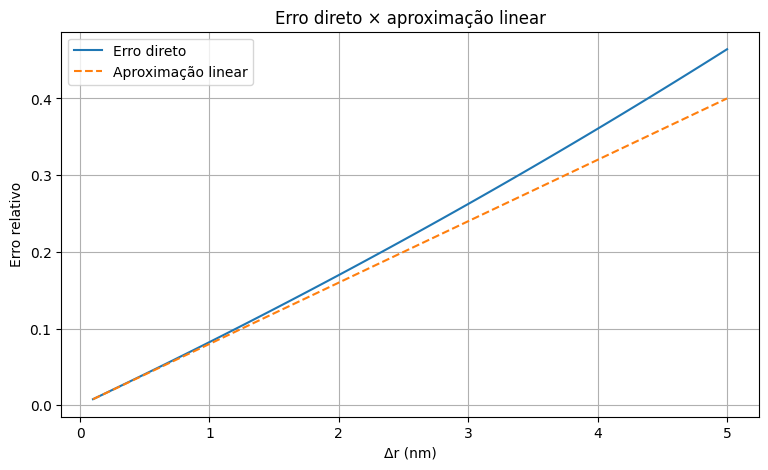

In [31]:
plt.figure(figsize=(9, 5))

plt.plot(
    dr_nm,
    erro_rel_max,
    label="Erro direto"
)

plt.plot(
    dr_nm,
    aproximacao_linear,
    linestyle="--",
    label="Aproximação linear"
)

plt.xlabel("Δr (nm)")
plt.ylabel("Erro relativo")
plt.title("Erro direto × aproximação linear")
plt.grid(True)
plt.legend()

plt.show()

## **D.2 - Precisão Computacional**

float32 x float64

In [32]:
r32 = np.float32(r_nano)
r64 = np.float64(r_nano)

dp32 = np.float32(dp_nano)
dp64 = np.float64(dp_nano)

mu32 = np.float32(mu_nano)
mu64 = np.float64(mu_nano)

L32 = np.float32(L_nano)
L64 = np.float64(L_nano)

Calculando

In [33]:
r4_32 = r32**4
r4_64 = r64**4

Q32 = (
    np.float32(np.pi)
    * r32**4
    * dp32
    / (np.float32(8) * mu32 * L32)
)

Q64 = (
    np.float64(np.pi)
    * r64**4
    * dp64
    / (np.float64(8) * mu64 * L64)
)

Comparando:

In [34]:
diferenca_abs = abs(float(Q64) - float(Q32))

diferenca_rel = (
    diferenca_abs / abs(float(Q64))
)

print("float32")
print(f"r⁴ = {r4_32:.15e}")
print(f"Q = {Q32:.15e}")

print("\nfloat64")
print(f"r⁴ = {r4_64:.15e}")
print(f"Q = {Q64:.15e}")

print("\nDiferenças")
print(f"Erro absoluto = {diferenca_abs:.15e}")
print(f"Erro relativo = {diferenca_rel:.15e}")

float32
r⁴ = 6.250000395977423e-30
Q = 3.506242323744234e-19

float64
r⁴ = 6.249999999999999e-30
Q = 3.506241800881465e-19

Diferenças
Erro absoluto = 5.228627689184328e-26
Erro relativo = 1.491234200638945e-07


Assim:

In [35]:
print("Precisão da máquina:")
print("float32:", np.finfo(np.float32).eps)
print("float64:", np.finfo(np.float64).eps)

Precisão da máquina:
float32: 1.1920929e-07
float64: 2.220446049250313e-16


Como o enunciando quer comparar:
$$δ_1 =\frac{Q(r+Δr)−Q(r)} {Q(r)}$$	​
e
$$ δ_2=(1+\frac{Δr}{r})ˆ4 −1$$

Vamos fazer uma série de valores cada vez menores, assim:

In [36]:
fracoes = 10.0 ** np.arange(-1, -17, -1)

delta1 = []
delta2 = []

for fracao in fracoes:

    dr = r_nano * fracao

    Q1 = vazao(
        r_nano + dr,
        L_nano,
        mu_nano,
        dp_nano
    )

    d1 = (
        Q1 - Q_nano
    ) / Q_nano

    d2 = (
        1 + dr / r_nano
    )**4 - 1

    delta1.append(d1)
    delta2.append(d2)

Gerando a tabela:

In [37]:
tabela_cancelamento = pd.DataFrame({
    "Δr/r": fracoes,
    "δ1": delta1,
    "δ2": delta2
})

tabela_cancelamento

,Δr/r,δ1,δ2
0,1.000000e-01,4.641000e-01,4.641000e-01
1,1.000000e-02,4.060401e-02,4.060401e-02
2,1.000000e-03,4.006004e-03,4.006004e-03
3,1.000000e-04,4.000600e-04,4.000600e-04
4,1.000000e-05,4.000060e-05,4.000060e-05
5,1.000000e-06,4.000006e-06,4.000006e-06
6,1.000000e-07,4.000001e-07,4.000001e-07
7,1.000000e-08,4.000000e-08,4.000000e-08
8,1.000000e-09,4.000000e-09,4.000000e-09
9,1.000000e-10,4.000000e-10,4.000000e-10


Logo, podemos observar que, para valores extremamente pequenos, o cálculo envolvendo a subtração:

$$ Q(r+\Delta r)-Q(r) $$

pode sofrer cancelamento numérico, porque estamos subtraindo dois números muito próximos.

## **D.3 - Fenômeno Físico**

Em um nanocateter, a redução das dimensões aumenta a razão entre a superfície e o volume, fazendo com que os efeitos associados às paredes tenham maior importância em relação ao volume de fluido. Como consequência, os efeitos viscosos e de parede tornam-se mais relevantes para o escoamento. Além disso, a equação de Hagen–Poiseuille apresenta uma forte dependência da vazão com o raio, proporcional a \(r^4\), fazendo com que pequenas alterações geométricas provoquem grandes variações na vazão. Entretanto, possuir muitas casas decimais no resultado numérico não garante que o modelo físico seja igualmente preciso, pois precisão aritmética e validade do modelo são conceitos diferentes.

# **7. Parte E – Síntese visual**

Vamos criar uma figura de 1600x1000 pixels.

In [38]:
fig = plt.figure(figsize=(16, 10), dpi=100)

<Figure size 1600x1000 with 0 Axes>

Agora vamos colocar as informações:

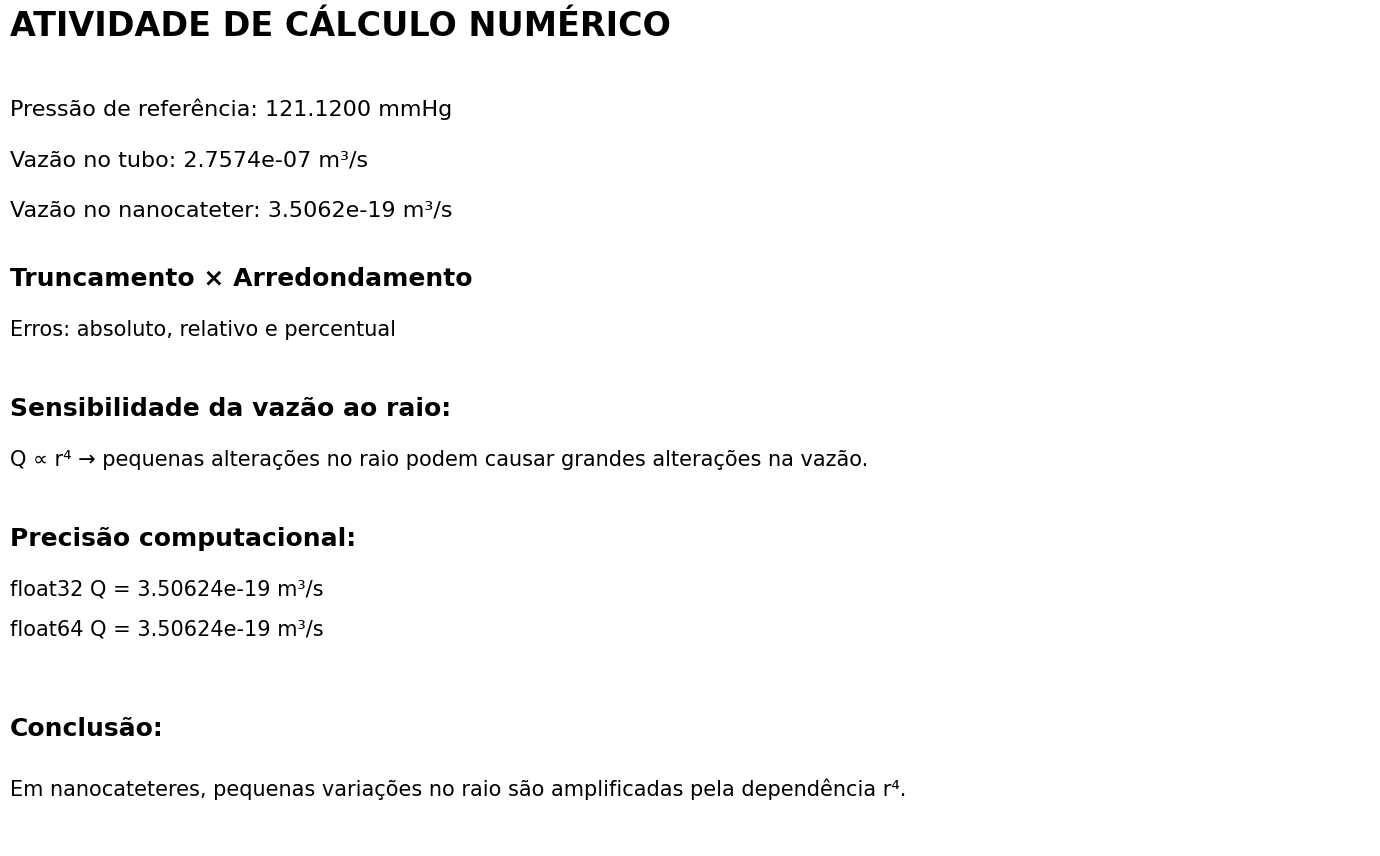

In [39]:
fig = plt.figure(figsize=(16, 10), dpi=100)

fig.text(
    0.05, 0.92,
    "ATIVIDADE DE CÁLCULO NUMÉRICO",
    fontsize=24,
    weight="bold"
)

fig.text(
    0.05, 0.84,
    f"Pressão de referência: {media_referencia:.4f} mmHg",
    fontsize=16
)

fig.text(
    0.05, 0.79,
    f"Vazão no tubo: {Q_ref:.4e} m³/s",
    fontsize=16
)

fig.text(
    0.05, 0.74,
    f"Vazão no nanocateter: {Q_nano:.4e} m³/s",
    fontsize=16
)

fig.text(
    0.05, 0.67,
    "Truncamento × Arredondamento",
    fontsize=18,
    weight="bold"
)

fig.text(
    0.05, 0.62,
    "Erros: absoluto, relativo e percentual",
    fontsize=15
)

fig.text(
    0.05, 0.54,
    "Sensibilidade da vazão ao raio:",
    fontsize=18,
    weight="bold"
)

fig.text(
    0.05, 0.49,
    "Q ∝ r⁴ → pequenas alterações no raio podem causar grandes alterações na vazão.",
    fontsize=15
)

fig.text(
    0.05, 0.41,
    "Precisão computacional:",
    fontsize=18,
    weight="bold"
)

fig.text(
    0.05, 0.36,
    f"float32 Q = {Q32:.5e} m³/s",
    fontsize=15
)

fig.text(
    0.05, 0.32,
    f"float64 Q = {Q64:.5e} m³/s",
    fontsize=15
)

fig.text(
    0.05, 0.22,
    "Conclusão:",
    fontsize=18,
    weight="bold"
)

fig.text(
    0.05, 0.16,
    "Em nanocateteres, pequenas variações no raio são amplificadas pela dependência r⁴.",
    fontsize=15
)

plt.axis("off")

plt.savefig(
    "quadro_resultados.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

# **8. GIF Demonstrativo**

In [40]:
raios_gif = np.linspace(45, 55, 40)

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

raios_completos = np.linspace(45, 55, 200)

Q_completos = vazao(
    raios_completos * 1e-9,
    L_nano,
    mu_nano,
    dp_nano
)

def atualizar(i):

    ax.clear()

    raio_nm = raios_gif[i]
    raio_m = raio_nm * 1e-9

    Q_atual = vazao(
        raio_m,
        L_nano,
        mu_nano,
        dp_nano
    )

    erro = abs(Q_atual - Q_nano) / Q_nano * 100

    # seção transversal
    circulo = plt.Circle(
        (0.2, 0.5),
        0.12 * raio_nm / 50,
        fill=False
    )

    ax.add_patch(circulo)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(
        0.05,
        0.85,
        f"Raio = {raio_nm:.2f} nm"
    )

    ax.text(
        0.05,
        0.78,
        f"Q = {Q_atual:.4e} m³/s"
    )

    ax.text(
        0.05,
        0.71,
        f"Erro = {erro:.4f}%"
    )

    # curva progressiva
    raios_atuais = raios_gif[:i+1]

    Q_atuais = vazao(
        raios_atuais * 1e-9,
        L_nano,
        mu_nano,
        dp_nano
    )

    ax2 = ax.inset_axes(
        [0.48, 0.15, 0.47, 0.7]
    )

    ax2.plot(
        raios_atuais,
        Q_atuais
    )

    ax2.set_xlabel("r (nm)")
    ax2.set_ylabel("Q (m³/s)")
    ax2.set_title("Q × r")

    ax.grid(True)

animacao = FuncAnimation(
    fig,
    atualizar,
    frames=len(raios_gif),
    interval=100
)

animacao.save(
    "nanocateter.gif",
    writer=PillowWriter(fps=10)
)

plt.close(fig)

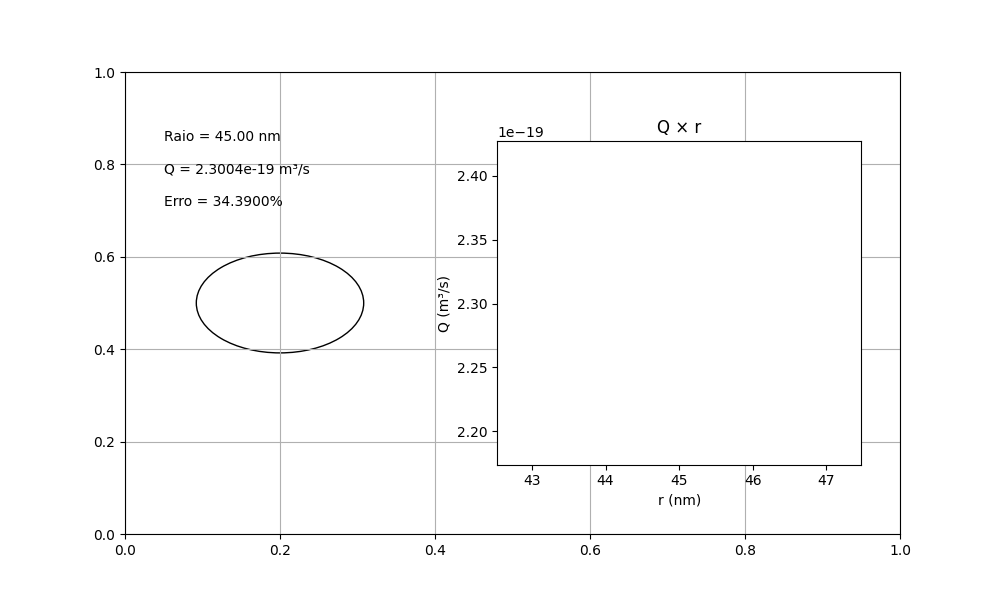

In [42]:
display(Image(filename="nanocateter.gif"))